# Практика 7. Візуалізація: Figure і Axes, підписи, гістограма, boxplot, діаграма розсіювання

**Варіант 1 — Київ.**

Мета: побудувати гістограму, boxplot і діаграму розсіювання через об'єктний інтерфейс Matplotlib (`Figure`, `Axes`), правильно підписати графіки та побачити механізм навмисного спотворення.

## Завдання 1. Побудова власного набору

Моделюємо продажі гарячих напоїв у кіоску Києва за 30 днів. Seed дорівнює номеру варіанта, тому результат відтворюється після кожного запуску. Вихідні дні — умовно кожен 6-й і 7-й день тижня.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

variant = 1
city = 'Київ'
product = 'гарячі напої'
base_sales = 40
base_temperature = 3

np.random.seed(variant)
days = np.arange(1, 31)
weekend = np.isin(days % 7, [6, 0])
temperature = np.round(base_temperature + np.random.uniform(-3, 3, size=30), 1)
random_variation = np.random.normal(0, 3, size=30)
sales = base_sales - 0.8 * (temperature - base_temperature) + random_variation
sales = np.rint(sales * np.where(weekend, 1.2, 1.0)).astype(int)

kiosk = pd.DataFrame({
    'день': days,
    'вихідний': weekend,
    'температура': temperature,
    'продажі': sales
})

print(f'Варіант {variant}: {city}; товар: {product}')
display(kiosk.head())
print('Розмір набору:', kiosk.shape)

Варіант 1: Київ; товар: гарячі напої


,день,вихідний,температура,продажі
0,1,False,2.5,40
1,2,False,4.3,36
2,3,False,0.0,43
3,4,False,1.8,43
4,5,False,0.9,38


Розмір набору: (30, 4)


## Завдання 2. Гістограма

Гістограма показує, скільки днів потрапляє в кожен інтервал продажів. Для 30 спостережень порівняємо 5 і 10 bins: 5 bins дає стабільнішу загальну картину, а 10 bins показує більше деталей, але може бути шумнішою.

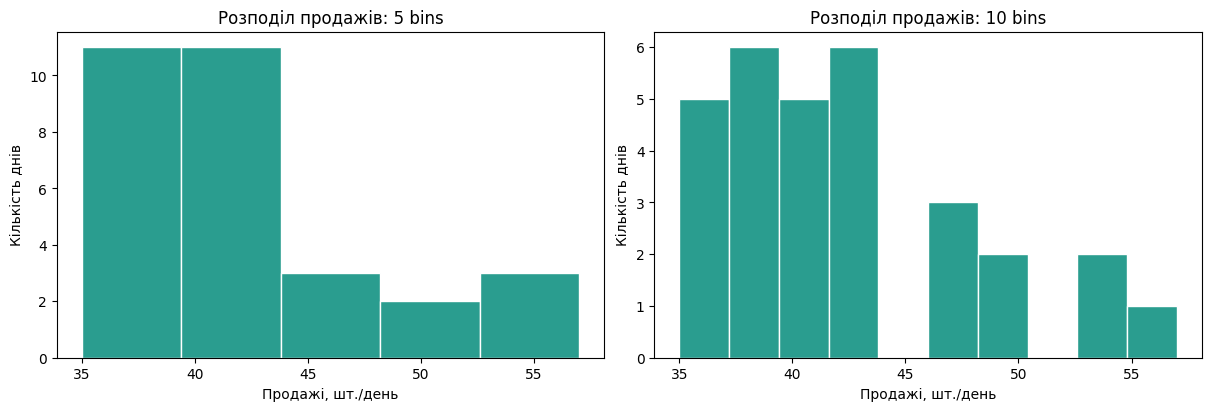

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, bins in zip(axes, [5, 10]):
    ax.hist(kiosk['продажі'], bins=bins, edgecolor='white', color='#2a9d8f')
    ax.set_xlabel('Продажі, шт./день')
    ax.set_ylabel('Кількість днів')
    ax.set_title(f'Розподіл продажів: {bins} bins')
plt.show()

**Висновок.** Для цього набору 5 bins краще показує загальну форму розподілу, оскільки спостережень лише 30 і надто вузькі інтервали можуть створити випадкові піки. 10 bins корисний для детальнішого огляду, але його висновки треба трактувати обережніше.

## Завдання 3. Boxplot

Порівняємо розподіл продажів у будні та вихідні. Обидва графіки нижче створюються через `fig, ax = plt.subplots()` та методи об'єкта `Axes`.

In [ ]:
weekdays = kiosk.loc[~kiosk['вихідний'], 'продажі']
weekends = kiosk.loc[kiosk['вихідний'], 'продажі']

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([weekdays, weekends], labels=['Будні', 'Вихідні'],
            patch_artist=True, boxprops={'facecolor': '#e9c46a'})
ax.set_xlabel('Тип дня')
ax.set_ylabel('Продажі, шт./день')
ax.set_title(f'Продажі {product}: будні проти вихідних')
plt.show()

print('Медіана буднів:', weekdays.median())
print('Медіана вихідних:', weekends.median())
print('IQR буднів:', weekdays.quantile(.75) - weekdays.quantile(.25))
print('IQR вихідних:', weekends.quantile(.75) - weekends.quantile(.25))

**Висновок.** Медіана продажів у вихідні має бути вищою, бо під час генерації до них застосовано множник 1.2. Розкид може бути більшим або меншим залежно від випадкової варіації, але саме зсув медіани узгоджується з умовою задачі.

## Завдання 4. Діаграма розсіювання

На осі X відкладаємо температуру, а на осі Y — продажі. Для гарячих напоїв очікується спадний зв'язок: за вищої температури попит може бути трохи нижчим, хоча вихідні та випадкова варіація додають розкиду.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(kiosk['температура'], kiosk['продажі'],
           color='#e76f51', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Температура повітря, °C')
ax.set_ylabel('Продажі, шт./день')
ax.set_title(f'Продажі {product} проти температури: {city}')
plt.show()

correlation = kiosk['температура'].corr(kiosk['продажі'])
print(f'Коефіцієнт кореляції Пірсона: {correlation:.3f}')

**Висновок.** На графіку очікується слабкий спадний напрямок: вищій температурі відповідають дещо нижчі продажі гарячих напоїв. Зв'язок не є ідеальним, бо на продажі одночасно впливають вихідний день і випадкова варіація. Кореляція описує асоціацію, а не доводить причинність.

## Завдання 5. Навмисно спотворений графік

Побудуємо один і той самий boxplot двічі. Ліворуч вісь Y починається з нуля, а праворуч її штучно обрізано. Числа не змінюються, але обрізана шкала перебільшує візуальну різницю між групами.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
groups = [weekdays, weekends]
labels = ['Будні', 'Вихідні']

axes[0].boxplot(groups, labels=labels, patch_artist=True,
                boxprops={'facecolor': '#2a9d8f'})
axes[0].set_ylim(0, None)
axes[0].set_xlabel('Тип дня')
axes[0].set_ylabel('Продажі, шт./день')
axes[0].set_title('Коректний масштаб')

axes[1].boxplot(groups, labels=labels, patch_artist=True,
                boxprops={'facecolor': '#e76f51'})
axes[1].set_ylim(30, 55)
axes[1].set_xlabel('Тип дня')
axes[1].set_ylabel('Продажі, шт./день')
axes[1].set_title('Спотворення: вісь Y обрізано')

plt.show()

**Пояснення спотворення.** Обрізана вісь Y порушує принцип чесного масштабу: відстань від 30 до 40 візуально виглядає майже такою самою, як від 40 до 50, хоча на повній шкалі нульовий початок дає правильнішу оцінку абсолютної різниці. Таке оформлення може створити враження дуже великої переваги вихідних, хоча різниця вимірюється лише кількома штуками на день.

## Контрольні питання

1. **Чому обрізана вісь Y перебільшує різницю?** Вона прибирає частину шкали, тому одна й та сама числова різниця займає більшу частину висоти графіка. Підписані числа можуть залишатися правильними, але візуальне співвідношення стає оманливим.

2. **Коли лінійний графік є помилкою?** Наприклад, не слід з'єднувати лінією середні продажі категорій `чай`, `кава`, `сік`, якщо порядок категорій довільний. Назви товарів належать до номінальної шкали, тому лінія неправильно натякає на безперервний числовий рух між ними.

3. **Чому підписи є частиною твердження?** Без назв осей, одиниць і заголовка незрозуміло, що вимірюється, у яких одиницях і яке питання відповідає графік. Підписи визначають інтерпретацію даних, а не просто прикрашають рисунок.

4. **Що таке chartjunk?** Це зайві декоративні елементи, наприклад 3D-ефекти, тіні або надмірні кольори. Вони ускладнюють порівняння величин і відволікають від даних, тому не додають графіку доказовості.

## Підсумок

Через `fig, ax = plt.subplots()` побудовано гістограму, boxplot і діаграму розсіювання. Усі коректні графіки мають назви осей, одиниці вимірювання та заголовки. Порівняння з обрізаною віссю показує, як саме порушення масштабу змінює сприйняття тієї самої статистики.